# 06. Merge assay metadata with compound counts

This script merges two sources:
- `summary_data.csv`: compound and substance counts per AID
- `filtered_description_with_organisms_v2_REBUILT.csv`: metadata including pathogen and ChEMBL ID

Output: `summary_bioassays.csv`

## 00. Setup

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Define paths
PROJECT_ROOT = Path("/Users/maria/Documents/Ersilia/PubChem/pubchem-antimicrobial-tasks")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

## 01. Load input files

In [3]:
summary_data = pd.read_csv(DATA_PROCESSED / "summary_data.csv")
summary_data = summary_data.sort_values('AID', ascending = True ).reset_index(drop = True)
summary_data.head(5)

,AID,substances_count,compound_count
0,365,206,205
1,375,10011,10009
2,448,64651,63782
3,547,1280,1274
4,555,65267,65241


In [132]:
# Check for an specific filtered AID
summary_data[summary_data["AID"]== 1626]

,AID,substances_count,compound_count
38,1626,215397,215098


In [133]:
summary_data[summary_data["AID"]== 1332]

,AID,substances_count,compound_count
22,1332,1118,1117


In [4]:
summary_description = pd.read_csv(DATA_PROCESSED / "filtered_description_with_organisms_v2_REBUILT.csv")
summary_description = summary_description.sort_values('AID', ascending = True ).reset_index(drop = True)
summary_description

,AID,Pathogen,ChEMBLid,TaxID_AssayTarget,TaxID_XRef,TaxID_ResultType,TaxIDs_All,AssayOrganism
0,365,Escherichia coli,NaN,[],['562'],[],['562'],[]
1,375,Mycobacterium tuberculosis,NaN,[],['1773'],[],['1773'],"['Mycobacterium tuberculosis', 'MYCOBACTERIUM ..."
2,448,Schistosoma mansoni,NaN,[],['6183'],[],['6183'],[]
3,547,Escherichia coli,NaN,[],['83333'],[],['83333'],"['molecular chaperone DnaK (dnaK).', 'molecula..."
4,555,Streptococcus pneumoniae,NaN,[],['373153'],[],['373153'],[]
...,...,...,...,...,...,...,...,...
129922,2061452,Pseudomonas aeruginosa,NaN,[],[],[],[],['INHIBITORS OF PSEUDOMONAS AERUGINOSA VIRULEN...
129923,2061453,Pseudomonas aeruginosa,NaN,[],[],[],[],['INHIBITORS OF PSEUDOMONAS AERUGINOSA VIRULEN...
129924,2061454,Pseudomonas aeruginosa,NaN,[],[],[],[],['INHIBITORS OF PSEUDOMONAS AERUGINOSA VIRULEN...
129925,2061455,Pseudomonas aeruginosa,NaN,[],[],[],[],['INHIBITORS OF PSEUDOMONAS AERUGINOSA VIRULEN...


In [135]:
# Check for an specific filtered AID
summary_description[summary_description["AID"]== 1626]
summary_description[summary_description["AID"]== 1332]

,AID,Pathogen,ChEMBLid,TaxID_AssayTarget,TaxID_XRef,TaxID_ResultType,TaxIDs_All,AssayOrganism,Has_ChEMBL
22,1332,Mycobacterium tuberculosis,NaN,[],['83332'],[],['83332'],[],False


## 02. Merge on AID

In [91]:
summary_bioassays = summary_data.merge(
    summary_description[["AID", "Pathogen", "ChEMBLid"]],
    on="AID",
    how="left"
)

summary_bioassays = summary_bioassays[["Pathogen", "AID", "compound_count", "substances_count", "ChEMBLid"]]

summary_bioassays = summary_bioassays.rename(columns={
    "AID": "PubChem_AID",
    "substances_count": "PubChem_substances",
    "compound_count": "PubChem_compounds",
    "ChEMBLid": "ChEMBL_ID"
})

summary_bioassays

,Pathogen,PubChem_AID,PubChem_compounds,PubChem_substances,ChEMBL_ID
0,Escherichia coli,365,205,206,NaN
1,Mycobacterium tuberculosis,375,10009,10011,NaN
2,Schistosoma mansoni,448,63782,64651,NaN
3,Escherichia coli,547,1274,1280,NaN
4,Streptococcus pneumoniae,555,65241,65267,NaN
...,...,...,...,...,...
129880,Pseudomonas aeruginosa,2061452,43,43,NaN
129881,Pseudomonas aeruginosa,2061453,4,4,NaN
129882,Pseudomonas aeruginosa,2061454,4,4,NaN
129883,Pseudomonas aeruginosa,2061455,4,4,NaN


## 03. Save output

In [92]:
PUBCHEM = DATA_PROCESSED / "PubChem_bioassays"
PUBCHEM.mkdir(parents=True, exist_ok=True)

summary_bioassays.to_csv(PUBCHEM / "summary_bioassays.csv", index=False)

## 04. Merge with ChEMBL dataframes

Some assays have more than one pathogen detected, because we have searched for taxid and assay organism.

In [93]:
summary_bioassays["Pathogen"].unique()

array(['Escherichia coli', 'Mycobacterium tuberculosis',
       'Schistosoma mansoni', 'Streptococcus pneumoniae',
       'Staphylococcus aureus', 'Pseudomonas aeruginosa',
       'Candida albicans', 'Escherichia coli, Mycobacterium tuberculosis',
       'Plasmodium falciparum', 'Enterobacter, Escherichia coli',
       'Acinetobacter baumannii', 'Enterobacter', 'Campylobacter',
       'Klebsiella pneumoniae', 'Helicobacter pylori',
       'Enterococcus faecium', 'Neisseria gonorrhoeae',
       'Escherichia coli, Pseudomonas aeruginosa',
       'Escherichia coli, Helicobacter pylori',
       'Acinetobacter baumannii, Candida albicans, Escherichia coli, Mycobacterium tuberculosis, Staphylococcus aureus'],
      dtype=object)

In [94]:
# Convert Pathogen column to string, just in case
summary_bioassays["Pathogen"] = summary_bioassays["Pathogen"].astype(str)

# Convert to list (split by comma + space)
summary_bioassays["Pathogen_list"] = summary_bioassays["Pathogen"].str.split(", ")

# Find rows with >1 pathogen
multi_pathogen_rows = summary_bioassays[summary_bioassays["Pathogen_list"].apply(len) > 1].copy()

# Create a clean string version for display or export (optional)
multi_pathogen_rows["Pathogen_str"] = multi_pathogen_rows["Pathogen_list"].apply(lambda x: ", ".join(x))

# Show count and preview
print(f"Multi-pathogen assays: {len(multi_pathogen_rows)}")
multi_pathogen_rows[["PubChem_AID", "Pathogen_str"]]

Multi-pathogen assays: 22


,PubChem_AID,Pathogen_str
23,1376,"Escherichia coli, Mycobacterium tuberculosis"
27,1494,"Enterobacter, Escherichia coli"
29224,463099,"Escherichia coli, Pseudomonas aeruginosa"
29225,463100,"Escherichia coli, Pseudomonas aeruginosa"
30596,488955,"Escherichia coli, Helicobacter pylori"
30825,492957,"Escherichia coli, Helicobacter pylori"
55902,623916,"Escherichia coli, Helicobacter pylori"
55903,623917,"Escherichia coli, Helicobacter pylori"
55904,623918,"Escherichia coli, Helicobacter pylori"
55905,623919,"Escherichia coli, Helicobacter pylori"


In [95]:
# Get list of AIDs with multiple pathogens
aids_to_exclude = set(multi_pathogen_rows["PubChem_AID"])

# Filter df to exclude those AIDs
summary_bioassays = summary_bioassays[~summary_bioassays["PubChem_AID"].isin(aids_to_exclude)]
summary_bioassays = summary_bioassays.drop(columns = ['Pathogen_list'])
summary_bioassays

,Pathogen,PubChem_AID,PubChem_compounds,PubChem_substances,ChEMBL_ID
0,Escherichia coli,365,205,206,NaN
1,Mycobacterium tuberculosis,375,10009,10011,NaN
2,Schistosoma mansoni,448,63782,64651,NaN
3,Escherichia coli,547,1274,1280,NaN
4,Streptococcus pneumoniae,555,65241,65267,NaN
...,...,...,...,...,...
129880,Pseudomonas aeruginosa,2061452,43,43,NaN
129881,Pseudomonas aeruginosa,2061453,4,4,NaN
129882,Pseudomonas aeruginosa,2061454,4,4,NaN
129883,Pseudomonas aeruginosa,2061455,4,4,NaN


In [96]:
# Prepare list of pathogen files (from Arnau's ChEMBL project)
pathogen_dir = DATA_PROCESSED / "ChEMBL_bioassays"
pathogen_files = list(pathogen_dir.glob("*_ChEMBL_data.csv"))

# Initialize empty list to collect all [assay_id, cpds] rows
cpds_rows = []

# Process each pathogen file
for file in pathogen_files:
    df = pd.read_csv(file, low_memory=False)
    if "assay_chembl_id" in df.columns and "compound_chembl_id" in df.columns:
        tmp = df.groupby("assay_chembl_id")["compound_chembl_id"].nunique().reset_index()
        tmp = tmp.rename(columns={"assay_chembl_id": "ChEMBL_ID", "compound_chembl_id": "ChEMBL_compounds"})
        cpds_rows.append(tmp)

# Concatenate all assay-level compound counts
df_cpds = pd.concat(cpds_rows).drop_duplicates(subset=["ChEMBL_ID"])

# Merge into summary
summary_bioassays = summary_bioassays.merge(df_cpds, on="ChEMBL_ID", how="left")

# Fill missing counts with 0 and convert to integer
summary_bioassays["ChEMBL_compounds"] = summary_bioassays["ChEMBL_compounds"].fillna(0).astype(int)

# Save updated summary
summary_bioassays.to_csv(DATA_PROCESSED / "summary_bioassays_with_chembl_compounds.csv", index=False)

summary_bioassays.head()

,Pathogen,PubChem_AID,PubChem_compounds,PubChem_substances,ChEMBL_ID,ChEMBL_compounds
0,Escherichia coli,365,205,206,NaN,0
1,Mycobacterium tuberculosis,375,10009,10011,NaN,0
2,Schistosoma mansoni,448,63782,64651,NaN,0
3,Escherichia coli,547,1274,1280,NaN,0
4,Streptococcus pneumoniae,555,65241,65267,NaN,0


## 06. Check number of compounds in PubChem vs ChEMBL

In [115]:
# Checking if compounds numbers are equal in PubChem vs ChEMBL

summary_bioassays["same_compound_count"] = (
    summary_bioassays["PubChem_compounds"] == summary_bioassays["ChEMBL_compounds"]
)

summary_bioassays["compound_diff"] = (
    summary_bioassays["PubChem_compounds"] - summary_bioassays["ChEMBL_compounds"]
)

summary_bioassays.to_csv(DATA_PROCESSED / "summary_bioassays_with_chembl_compounds.csv", index=False)

In [116]:
summary_bioassays

,Pathogen,PubChem_AID,PubChem_compounds,PubChem_substances,ChEMBL_ID,ChEMBL_compounds,same_compound_count,compound_diff
0,Escherichia coli,365,205,206,NaN,0,False,205
1,Mycobacterium tuberculosis,375,10009,10011,NaN,0,False,10009
2,Schistosoma mansoni,448,63782,64651,NaN,0,False,63782
3,Escherichia coli,547,1274,1280,NaN,0,False,1274
4,Streptococcus pneumoniae,555,65241,65267,NaN,0,False,65241
...,...,...,...,...,...,...,...,...
129858,Pseudomonas aeruginosa,2061452,43,43,NaN,0,False,43
129859,Pseudomonas aeruginosa,2061453,4,4,NaN,0,False,4
129860,Pseudomonas aeruginosa,2061454,4,4,NaN,0,False,4
129861,Pseudomonas aeruginosa,2061455,4,4,NaN,0,False,4


In [117]:
# Group by pathogen
summary_pubchem_chembl = summary_bioassays.groupby("Pathogen").agg(
    PubChem_AIDs=("PubChem_AID", "nunique"),
    ChEMBL_IDs=("ChEMBL_ID", lambda x: x.notna().sum()),
    Matching_Compounds=("same_compound_count", "sum"),
    Total_with_ChEMBL=("same_compound_count", "count")  # Only rows with ChEMBL compound counts
).reset_index()


# Compute percentage of ChEMBL IDs
summary_pubchem_chembl["Percent_ChEMBL_IDs"] = (
    100 * summary_pubchem_chembl["ChEMBL_IDs"] / summary_pubchem_chembl["PubChem_AIDs"]
).round(1)

# Compute percentage of matched compounds (among only those with ChEMBL IDs)
summary_pubchem_chembl["Percent_Matching_Compounds"] = (
    100 * summary_pubchem_chembl["Matching_Compounds"] / summary_pubchem_chembl["Total_with_ChEMBL"]
).round(1)

# Drop intermediate column
summary_pubchem_chembl.drop(columns="Total_with_ChEMBL", inplace=True)

# Reorder columns
summary = summary_pubchem_chembl[
    ["Pathogen", "PubChem_AIDs", "ChEMBL_IDs", "Percent_ChEMBL_IDs", 
     "Matching_Compounds", "Percent_Matching_Compounds"]
]

summary_pubchem_chembl

,Pathogen,PubChem_AIDs,ChEMBL_IDs,Matching_Compounds,Percent_ChEMBL_IDs,Percent_Matching_Compounds
0,Acinetobacter baumannii,3580,3575,3286,99.9,91.8
1,Campylobacter,342,333,331,97.4,96.8
2,Candida albicans,13198,13105,11931,99.3,90.4
3,Enterobacter,2509,2509,1769,100.0,70.5
4,Enterococcus faecium,1995,1995,1950,100.0,97.7
5,Escherichia coli,24588,24497,24029,99.6,97.7
6,Helicobacter pylori,920,906,891,98.5,96.8
7,Klebsiella pneumoniae,5799,5799,5605,100.0,96.7
8,Mycobacterium tuberculosis,12735,12598,11816,98.9,92.8
9,Neisseria gonorrhoeae,500,500,498,100.0,99.6


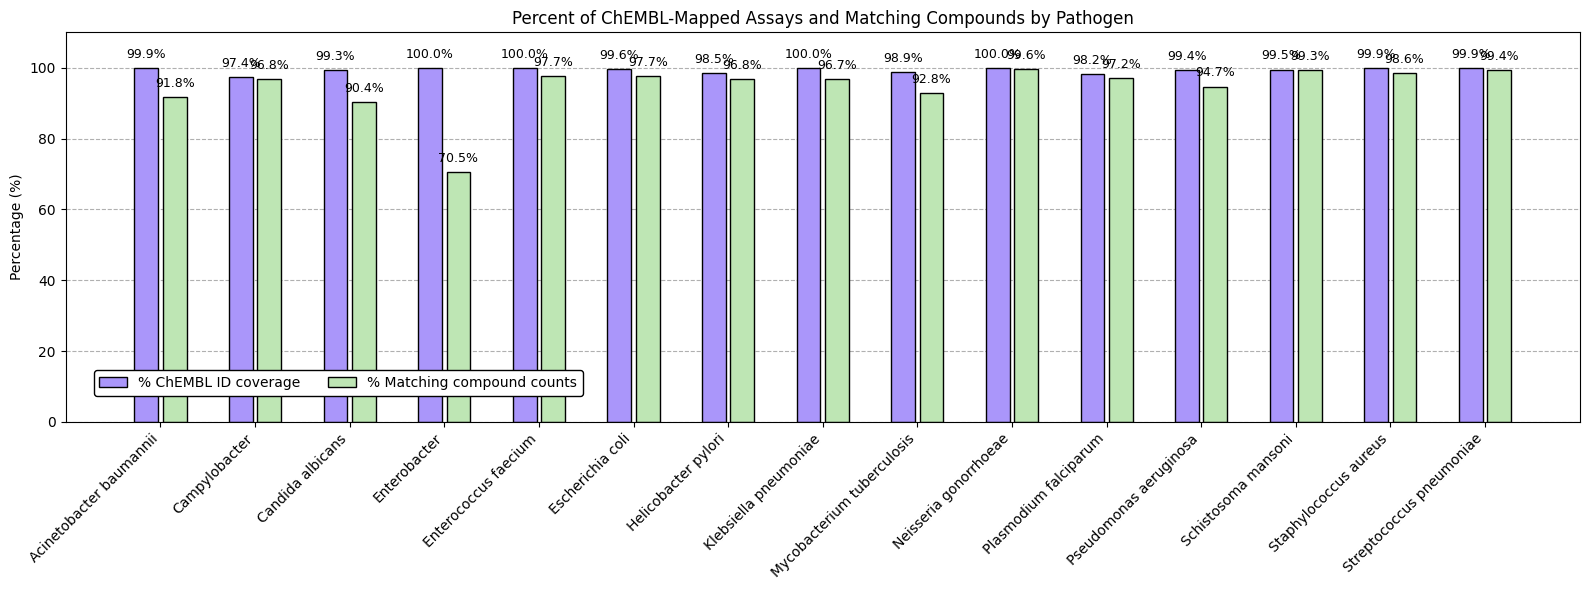

In [47]:
# Data
summary = summary_pubchem_chembl.copy()
labels = summary["Pathogen"].values
percent_chembl = summary["Percent_ChEMBL_IDs"].values
percent_matching = summary["Percent_Matching_Compounds"].values

N = len(labels)
x = np.arange(N)

# ⏩ Adjust spacing: smaller bar width + larger offset
bar_width = 0.25
bar_spacing = 0.15  # controls the separation inside each group

# Colors
color_chembl = "#AA96FA"    # Purple
color_match  = "#BEE6B4"    # Green

# Plot
plt.figure(figsize=(16, 6))

# 1. Bar: Percent_ChEMBL_IDs
bars1 = plt.bar(x - bar_spacing, percent_chembl, width=bar_width,
                color=color_chembl, ec="black", zorder=2, label="% ChEMBL ID coverage")

# 2. Bar: Percent_Matching_Compounds
bars2 = plt.bar(x + bar_spacing, percent_matching, width=bar_width,
                color=color_match, ec="black", zorder=2, label="% Matching compound counts")

# Add labels on top of bars
for i in range(N):
    plt.text(x[i] - bar_spacing, percent_chembl[i] + 2, f"{percent_chembl[i]:.1f}%",
             ha='center', va='bottom', fontsize=9, zorder=3)
    plt.text(x[i] + bar_spacing, percent_matching[i] + 2, f"{percent_matching[i]:.1f}%",
             ha='center', va='bottom', fontsize=9, zorder=3)

# Aesthetics
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Percentage (%)")
plt.ylim(0, 110)
plt.title("Percent of ChEMBL-Mapped Assays and Matching Compounds by Pathogen")
plt.grid(linestyle="--", zorder=1, axis="y")

# Legend at bottom
plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.18, 0.05),
    ncol=2,
    framealpha=1,
    edgecolor="k",
    prop={"size": 10}
)

plt.tight_layout()
plt.show()

In [118]:
# Get only rows with ChEMBL_id

ChEMBL_id = summary_bioassays[
    summary_bioassays["ChEMBL_ID"].notna()
].dropna(
    subset=["compound_diff", "Pathogen", "PubChem_compounds", "ChEMBL_compounds"]
).copy()

# Get top 10 assays with largest absolute difference (more compunds in top_PubChem)
top_PubChem = ChEMBL_id.loc[
    ChEMBL_id["compound_diff"].abs().nlargest(10).index,
    ["Pathogen", "PubChem_AID", "ChEMBL_ID", "PubChem_compounds", "ChEMBL_compounds", "compound_diff"]
]

# Clean index for display
top_PubChem = top_PubChem.reset_index(drop=True)

top_PubChem

,Pathogen,PubChem_AID,ChEMBL_ID,PubChem_compounds,ChEMBL_compounds,compound_diff
0,Mycobacterium tuberculosis,1992965,CHEMBL5345968,172,0,172
1,Mycobacterium tuberculosis,1992966,CHEMBL5345969,172,0,172
2,Candida albicans,1379938,CHEMBL4194370,122,0,122
3,Mycobacterium tuberculosis,1443445,CHEMBL4011043,103,0,103
4,Candida albicans,1595049,CHEMBL4393937,88,0,88
5,Enterobacter,1873908,CHEMBL5129402,85,0,85
6,Candida albicans,1265642,CHEMBL3745096,84,0,84
7,Candida albicans,1073866,CHEMBL3129216,82,0,82
8,Mycobacterium tuberculosis,57953,CHEMBL665360,78,0,78
9,Enterobacter,1308275,CHEMBL3820449,77,0,77


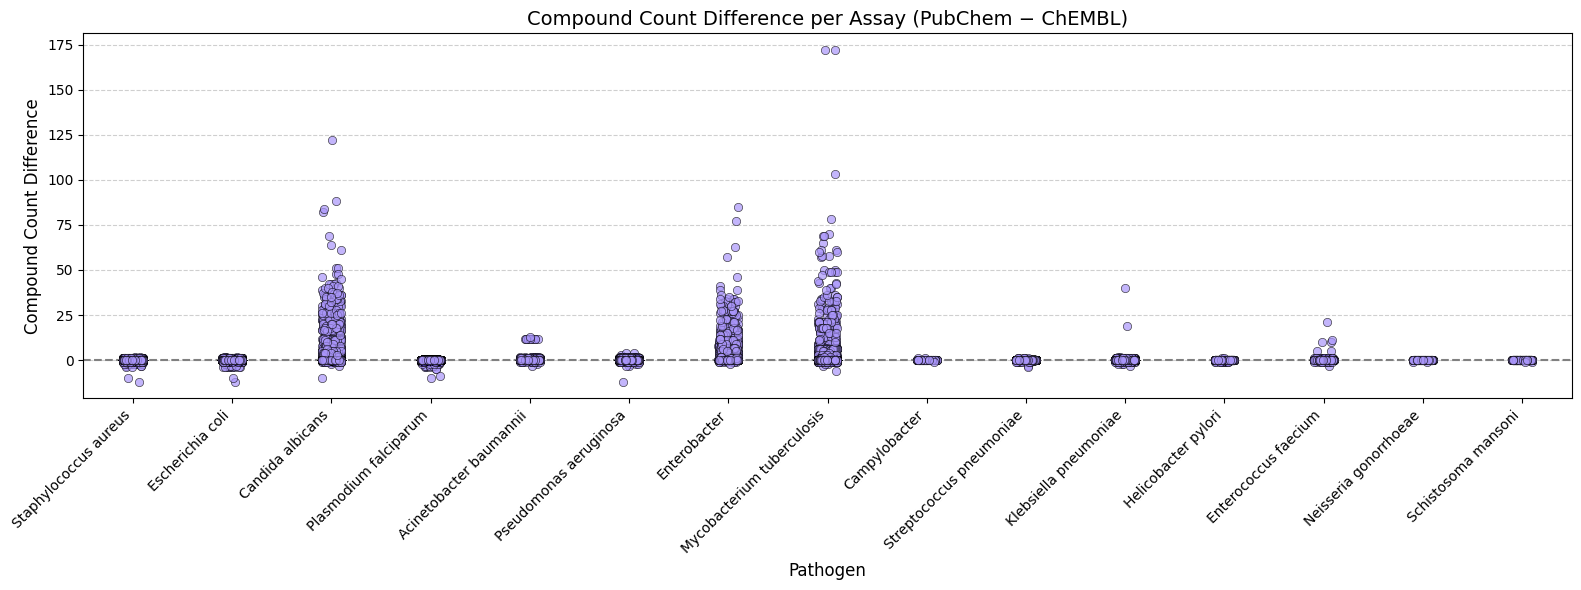

In [119]:
# Reuse ChEMBL_id-filtered DataFrame
ChEMBL_id = summary_bioassays[
    summary_bioassays["ChEMBL_ID"].notna()
].dropna(
    subset=["compound_diff", "Pathogen", "PubChem_compounds", "ChEMBL_compounds"]
).copy()

# Plot: Compound Count Difference per Assay (only those with ChEMBL ID)
plt.figure(figsize=(16, 6))
sns.stripplot(
    data=ChEMBL_id,
    x="Pathogen",
    y="compound_diff",
    jitter=True,
    alpha=0.7,
    size=6,
    linewidth=0.5,
    edgecolor="black",
    color="#AA96FA"  # match with previous purple bar
)

plt.axhline(0, linestyle="--", color="gray")
plt.title("Compound Count Difference per Assay (PubChem − ChEMBL)", fontsize=14)
plt.ylabel("Compound Count Difference", fontsize=12)
plt.xlabel("Pathogen", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [53]:
# Bottom 10: ChEMBL >> PubChem
bottom_ChEMBL = ChEMBL_id.loc[
    ChEMBL_id["compound_diff"].nsmallest(10).index,
    ["Pathogen", "PubChem_AID", "ChEMBL_ID", "PubChem_compounds", "ChEMBL_compounds", "compound_diff"]
].reset_index(drop=True)

bottom_ChEMBL

,Pathogen,PubChem_AID,ChEMBL_ID,PubChem_compounds,ChEMBL_compounds,compound_diff
0,Pseudomonas aeruginosa,718840,CHEMBL2215743,13,25,-12
1,Escherichia coli,718841,CHEMBL2215744,13,25,-12
2,Staphylococcus aureus,718842,CHEMBL2215745,13,25,-12
3,Plasmodium falciparum,496819,CHEMBL1217000,618,628,-10
4,Candida albicans,1084894,CHEMBL3061505,12,22,-10
5,Escherichia coli,1084896,CHEMBL3062063,12,22,-10
6,Staphylococcus aureus,1084897,CHEMBL3062064,12,22,-10
7,Plasmodium falciparum,1786108,CHEMBL4888485,147420,147429,-9
8,Mycobacterium tuberculosis,661399,CHEMBL2032580,130,136,-6
9,Plasmodium falciparum,524794,CHEMBL1267249,559,564,-5


### New file to compare number of compunds

In [104]:
# Lod new file
assays_ChEMBL = pd.read_csv(DATA_PROCESSED / "ChEMBL_bioassays" / "assays_ChEMBL.csv")
assays_ChEMBL.head()

,assay_id,assay_type,assay_organism,doc_chembl_id,target_type,target_chembl_id,target_organism,activity_type,unit,activities,nan_values,cpds
0,CHEMBL4649948,F,Mycobacterium tuberculosis,CHEMBL3988442,UNCHECKED,CHEMBL612545,NaN,PERCENTEFFECT,%,93555,0,86589
1,CHEMBL4649949,F,Mycobacterium tuberculosis,CHEMBL3988442,UNCHECKED,CHEMBL612545,NaN,PERCENTEFFECT,%,101515,0,86575
2,CHEMBL4649971,F,Mycobacterium tuberculosis,CHEMBL3988442,ORGANISM,CHEMBL360,Mycobacterium tuberculosis,PERCENTEFFECT,%,68619,0,68613
3,CHEMBL4649972,F,Mycobacterium tuberculosis,CHEMBL3988442,PROTEIN COMPLEX,CHEMBL4662931,Mycobacterium tuberculosis (strain ATCC 25618 ...,PERCENTEFFECT,%,68616,0,68610
4,CHEMBL4649941,F,Mycobacterium tuberculosis,CHEMBL3988442,SINGLE PROTEIN,CHEMBL4662928,Mycobacterium tuberculosis (strain ATCC 25618 ...,PERCENTEFFECT,%,67381,0,66941


In [106]:
# Merge data from PubChem and from ChEMBL
import pandas as pd

# --- Load original dataframes ---
df1 = summary_bioassays.copy()       # Pathogen, PubChem_AID, PubChem_compounds, ChEMBL_ID
df2 = assays_ChEMBL.copy()           # assay_id, cpds

# --- Standardize ChEMBL IDs ---

# Remove "CHEMBL" prefix in assays_ChEMBL
df2["ChEMBL_ID_clean"] = df2["assay_id"].astype(str).str.replace("CHEMBL", "", regex=False)

# Remove any accidental prefix in summary_bioassays (safe to run)
df1["ChEMBL_ID_clean"] = df1["ChEMBL_ID"].astype(str).str.replace("CHEMBL", "", regex=False)

# --- Select required columns ---
df1_small = df1[[
    "Pathogen", "PubChem_AID", "PubChem_compounds", "ChEMBL_ID", "ChEMBL_ID_clean"
]]

df2_small = df2[[
    "assay_id", "cpds", "ChEMBL_ID_clean"
]]

# --- Merge ---
summary_bioassays_2 = df1_small.merge(
    df2_small,
    on="ChEMBL_ID_clean",
    how="left"
)

# --- Optional clean-up: drop helper column ---
summary_bioassays_2.drop(columns=["ChEMBL_ID_clean"], inplace=True)

# --- Preview ---
summary_bioassays_2.head()


,Pathogen,PubChem_AID,PubChem_compounds,ChEMBL_ID,assay_id,cpds
0,Escherichia coli,365,205,NaN,NaN,NaN
1,Mycobacterium tuberculosis,375,10009,NaN,NaN,NaN
2,Schistosoma mansoni,448,63782,NaN,NaN,NaN
3,Escherichia coli,547,1274,NaN,NaN,NaN
4,Streptococcus pneumoniae,555,65241,NaN,NaN,NaN


In [122]:
# Checking if compounds numbers are equal in PubChem vs ChEMBL

summary_bioassays_2["same_compound_count"] = (
    summary_bioassays_2["PubChem_compounds"] == summary_bioassays_2["cpds"]
)

summary_bioassays_2["compound_diff"] = (
    summary_bioassays_2["PubChem_compounds"] - summary_bioassays_2["cpds"]
)

summary_bioassays_2.to_csv(DATA_PROCESSED / "summary_bioassays_with_chembl_compounds_2.csv", index=False)

In [123]:
summary_bioassays_2.head()

,Pathogen,PubChem_AID,PubChem_compounds,ChEMBL_ID,assay_id,cpds,same_compound_count,compound_diff
0,Escherichia coli,365,205,NaN,NaN,NaN,False,NaN
1,Mycobacterium tuberculosis,375,10009,NaN,NaN,NaN,False,NaN
2,Schistosoma mansoni,448,63782,NaN,NaN,NaN,False,NaN
3,Escherichia coli,547,1274,NaN,NaN,NaN,False,NaN
4,Streptococcus pneumoniae,555,65241,NaN,NaN,NaN,False,NaN


In [110]:
# Group by pathogen
summary_pubchem_chembl_2 = summary_bioassays_2.groupby("Pathogen").agg(
    PubChem_AIDs=("PubChem_AID", "nunique"),
    ChEMBL_IDs=("ChEMBL_ID", lambda x: x.notna().sum()),
    Matching_Compounds=("same_compound_count", "sum"),
    Total_with_ChEMBL=("same_compound_count", "count")  # Only rows with ChEMBL compound counts
).reset_index()


# Compute percentage of ChEMBL IDs
summary_pubchem_chembl_2["Percent_ChEMBL_IDs"] = (
    100 * summary_pubchem_chembl_2["ChEMBL_IDs"] / summary_pubchem_chembl_2["PubChem_AIDs"]
).round(1)

# Compute percentage of matched compounds (among only those with ChEMBL IDs)
summary_pubchem_chembl_2["Percent_Matching_Compounds"] = (
    100 * summary_pubchem_chembl_2["Matching_Compounds"] / summary_pubchem_chembl_2["Total_with_ChEMBL"]
).round(1)

# Drop intermediate column
summary_pubchem_chembl_2.drop(columns="Total_with_ChEMBL", inplace=True)

# Reorder columns
summary = summary_pubchem_chembl_2[
    ["Pathogen", "PubChem_AIDs", "ChEMBL_IDs", "Percent_ChEMBL_IDs", 
     "Matching_Compounds", "Percent_Matching_Compounds"]
]

summary_pubchem_chembl_2

,Pathogen,PubChem_AIDs,ChEMBL_IDs,Matching_Compounds,Percent_ChEMBL_IDs,Percent_Matching_Compounds
0,Acinetobacter baumannii,3580,3575,0,99.9,0.0
1,Campylobacter,342,333,0,97.4,0.0
2,Candida albicans,13198,13105,0,99.3,0.0
3,Enterobacter,2509,2509,0,100.0,0.0
4,Enterococcus faecium,1995,1995,0,100.0,0.0
5,Escherichia coli,24588,24497,0,99.6,0.0
6,Helicobacter pylori,920,906,0,98.5,0.0
7,Klebsiella pneumoniae,5799,5799,0,100.0,0.0
8,Mycobacterium tuberculosis,12735,13731,11281,107.8,81.3
9,Neisseria gonorrhoeae,500,500,0,100.0,0.0


In [130]:
# Step 1: Filter to rows with ChEMBL_ID
df_valid = summary_bioassays_2[summary_bioassays_2["ChEMBL_ID"].notna()].copy()

# Step 2: Check for duplicate ChEMBL_IDs
duplicated_ids = df_valid["ChEMBL_ID"].duplicated(keep=False)
num_duplicates = duplicated_ids.sum()

if num_duplicates > 0:
    print(f"⚠️ Found {num_duplicates} duplicated ChEMBL_ID entries. Dropping duplicates to ensure uniqueness.")
    # Optional: print them
    # print(df_valid[duplicated_ids].sort_values("ChEMBL_ID"))
    
    # Drop duplicates keeping the first occurrence
    df_valid = df_valid.drop_duplicates(subset="ChEMBL_ID", keep="first")

⚠️ Found 2115 duplicated ChEMBL_ID entries. Dropping duplicates to ensure uniqueness.


In [131]:
# Find duplicated ChEMBL_IDs (show all duplicates, not just the second+ occurrence)
duplicates = summary_bioassays_2[summary_bioassays_2["ChEMBL_ID"].duplicated(keep=False)]

# Sort for easier inspection
duplicates_sorted = duplicates.sort_values("ChEMBL_ID")

# Display the first few rows
duplicates_sorted.head(20)

,Pathogen,PubChem_AID,PubChem_compounds,ChEMBL_ID,assay_id,cpds,same_compound_count,compound_diff
17735,Mycobacterium tuberculosis,333069,19,CHEMBL1000111,CHEMBL1000111,12.0,False,7.0
17736,Mycobacterium tuberculosis,333069,19,CHEMBL1000111,CHEMBL1000111,7.0,False,12.0
18924,Mycobacterium tuberculosis,348114,31,CHEMBL1000132,CHEMBL1000132,30.0,False,1.0
18925,Mycobacterium tuberculosis,348114,31,CHEMBL1000132,CHEMBL1000132,1.0,False,30.0
18930,Mycobacterium tuberculosis,348177,11,CHEMBL1001118,CHEMBL1001118,10.0,False,1.0
18931,Mycobacterium tuberculosis,348177,11,CHEMBL1001118,CHEMBL1001118,1.0,False,10.0
18932,Mycobacterium tuberculosis,348178,11,CHEMBL1001119,CHEMBL1001119,10.0,False,1.0
18933,Mycobacterium tuberculosis,348178,11,CHEMBL1001119,CHEMBL1001119,1.0,False,10.0
20119,Mycobacterium tuberculosis,362954,41,CHEMBL1003170,CHEMBL1003170,23.0,False,18.0
20120,Mycobacterium tuberculosis,362954,41,CHEMBL1003170,CHEMBL1003170,18.0,False,23.0


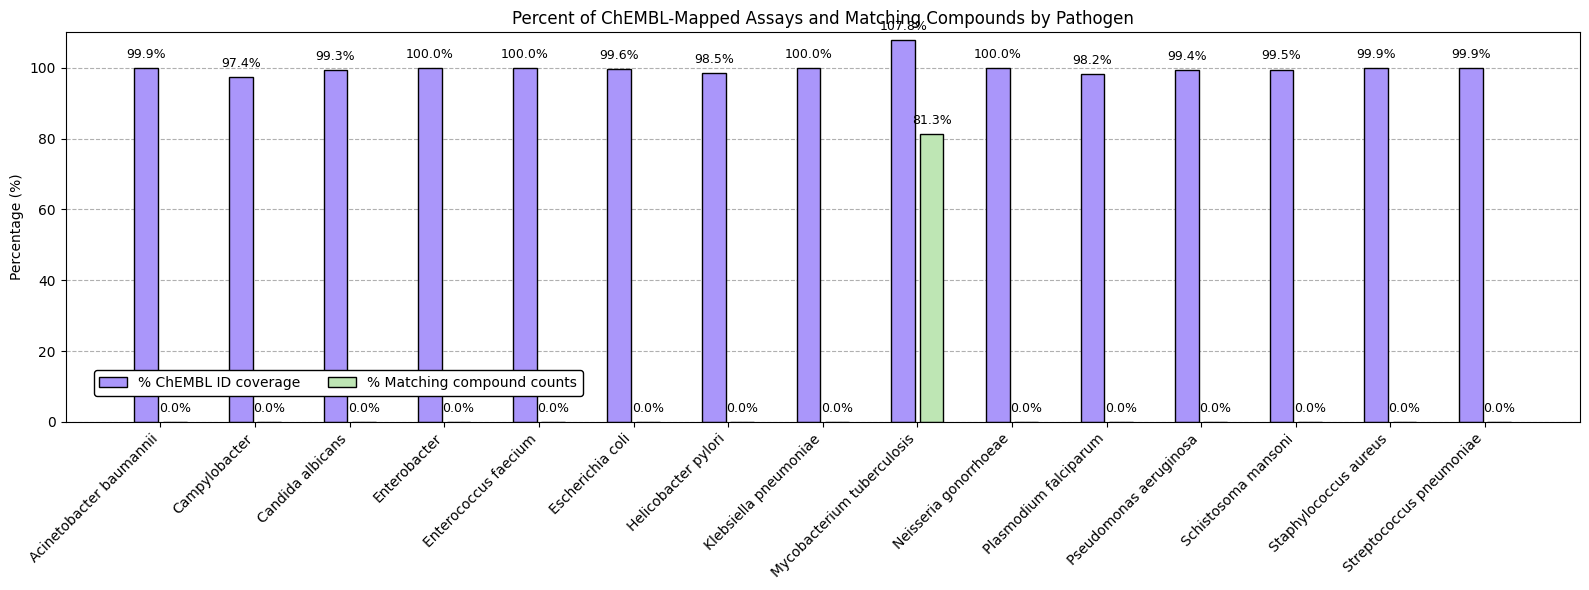

In [129]:
# Data
summary = summary_pubchem_chembl_2.copy()
labels = summary["Pathogen"].values
percent_chembl = summary["Percent_ChEMBL_IDs"].values
percent_matching = summary["Percent_Matching_Compounds"].values

N = len(labels)
x = np.arange(N)

# ⏩ Adjust spacing: smaller bar width + larger offset
bar_width = 0.25
bar_spacing = 0.15  # controls the separation inside each group

# Colors
color_chembl = "#AA96FA"    # Purple
color_match  = "#BEE6B4"    # Green

# Plot
plt.figure(figsize=(16, 6))

# 1. Bar: Percent_ChEMBL_IDs
bars1 = plt.bar(x - bar_spacing, percent_chembl, width=bar_width,
                color=color_chembl, ec="black", zorder=2, label="% ChEMBL ID coverage")

# 2. Bar: Percent_Matching_Compounds
bars2 = plt.bar(x + bar_spacing, percent_matching, width=bar_width,
                color=color_match, ec="black", zorder=2, label="% Matching compound counts")

# Add labels on top of bars
for i in range(N):
    plt.text(x[i] - bar_spacing, percent_chembl[i] + 2, f"{percent_chembl[i]:.1f}%",
             ha='center', va='bottom', fontsize=9, zorder=3)
    plt.text(x[i] + bar_spacing, percent_matching[i] + 2, f"{percent_matching[i]:.1f}%",
             ha='center', va='bottom', fontsize=9, zorder=3)

# Aesthetics
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Percentage (%)")
plt.ylim(0, 110)
plt.title("Percent of ChEMBL-Mapped Assays and Matching Compounds by Pathogen")
plt.grid(linestyle="--", zorder=1, axis="y")

# Legend at bottom
plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.18, 0.05),
    ncol=2,
    framealpha=1,
    edgecolor="k",
    prop={"size": 10}
)

plt.tight_layout()
plt.show()

In [125]:
# Get only rows with ChEMBL_id

ChEMBL_id = summary_bioassays_2[
    summary_bioassays_2["ChEMBL_ID"].notna()
].dropna(
    subset=["compound_diff", "Pathogen", "PubChem_compounds", "cpds"]
).copy()

# Get top 10 assays with largest absolute difference (more compunds in top_PubChem)
top_PubChem = ChEMBL_id.loc[
    ChEMBL_id["compound_diff"].abs().nlargest(10).index,
    ["Pathogen", "PubChem_AID", "ChEMBL_ID", "PubChem_compounds", "cpds", "compound_diff"]
]

# Clean index for display
top_PubChem = top_PubChem.reset_index(drop=True)

top_PubChem

,Pathogen,PubChem_AID,ChEMBL_ID,PubChem_compounds,cpds,compound_diff
0,Mycobacterium tuberculosis,1671161,CHEMBL4649948,86589,2466.0,84123.0
1,Mycobacterium tuberculosis,1671162,CHEMBL4649949,86575,2468.0,84107.0
2,Mycobacterium tuberculosis,1671184,CHEMBL4649971,68613,200.0,68413.0
3,Mycobacterium tuberculosis,1671185,CHEMBL4649972,68610,674.0,67936.0
4,Mycobacterium tuberculosis,1671154,CHEMBL4649941,66941,439.0,66502.0
5,Mycobacterium tuberculosis,1671178,CHEMBL4649965,66591,302.0,66289.0
6,Mycobacterium tuberculosis,1671170,CHEMBL4649957,65365,597.0,64768.0
7,Mycobacterium tuberculosis,1671160,CHEMBL4649947,8841,16.0,8825.0
8,Mycobacterium tuberculosis,1671170,CHEMBL4649957,65365,65027.0,338.0
9,Mycobacterium tuberculosis,1943293,CHEMBL5246869,92,1.0,91.0


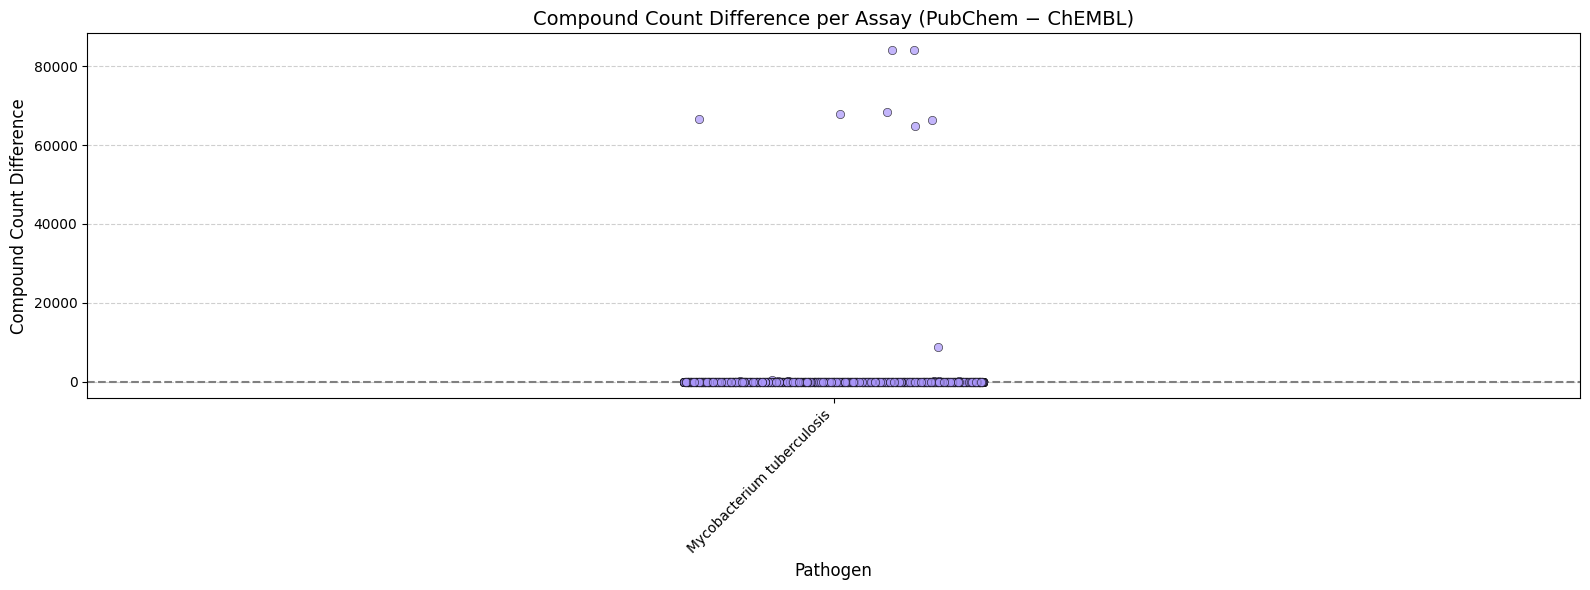

In [128]:
# Reuse ChEMBL_id-filtered DataFrame
ChEMBL_id = summary_bioassays_2[
    summary_bioassays_2["ChEMBL_ID"].notna()
].dropna(
    subset=["compound_diff", "Pathogen", "PubChem_compounds", "cpds"]
).copy()

# Plot: Compound Count Difference per Assay (only those with ChEMBL ID)
plt.figure(figsize=(16, 6))
sns.stripplot(
    data=ChEMBL_id,
    x="Pathogen",
    y="compound_diff",
    jitter=True,
    alpha=0.7,
    size=6,
    linewidth=0.5,
    edgecolor="black",
    color="#AA96FA"  # match with previous purple bar
)

plt.axhline(0, linestyle="--", color="gray")
plt.title("Compound Count Difference per Assay (PubChem − ChEMBL)", fontsize=14)
plt.ylabel("Compound Count Difference", fontsize=12)
plt.xlabel("Pathogen", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 07. ChEMBL_id found in PubChem

In [59]:
# Paths
pathogen_dir = DATA_PROCESSED / "ChEMBL_bioassays"

# Prepare set for faster lookup
arnau_chembl_ids = set(summary_bioassays["ChEMBL_ID"].dropna().astype(str))

# Mapping from short names in filenames → full pathogen names in summary_bioassays
pathogen_name_map = {
    "ecoli": "Escherichia coli",
    "saureus": "Staphylococcus aureus",
    "mtuberculosis": "Mycobacterium tuberculosis",
    "calbicans": "Candida albicans",
    "paeruginosa": "Pseudomonas aeruginosa",
    "kpneumoniae": "Klebsiella pneumoniae",
    "efaecium": "Enterococcus faecium",
    "pfalciparum": "Plasmodium falciparum",
    "abaumannii": "Acinetobacter baumannii",
    "enterobacter": "Enterobacter",
    "campylobacter": "Campylobacter",
    "smansoni": "Schistosoma mansoni",
    "hpylori": "Helicobacter pylori",
    "ngonorrhoeae": "Neisseria gonorrhoeae",
    "spneumoniae": "Streptococcus pneumoniae"
}

# Loop through pathogen files
rows = []
for file in pathogen_dir.glob("*_ChEMBL_data.csv"):
    df = pd.read_csv(file)
    short_name = file.stem.split("_ChEMBL_data")[0]
    pathogen_name = pathogen_name_map.get(short_name, short_name)  # fallback if not in dict

    file_chembl_ids = df["assay_chembl_id"].dropna().astype(str).unique()
    total = len(file_chembl_ids)
    matched = sum(aid in arnau_chembl_ids for aid in file_chembl_ids)
    percent = round(100 * matched / total, 1) if total > 0 else 0.0

    rows.append({
        "Pathogen": pathogen_name,
        "ChEMBL_assays_in_file": total,
        "Matched_in_summary": matched,
        "Percent_matched": percent
    })

chembl_match_summary = pd.DataFrame(rows).sort_values("Percent_matched", ascending=False)
chembl_match_summary

/var/folders/xk/plgt8lts2_72l0rtt_cz7k6h0000gn/T/ipykernel_7328/64665541.py:29: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


,Pathogen,ChEMBL_assays_in_file,Matched_in_summary,Percent_matched
14,Campylobacter,437,432,98.9
1,Helicobacter pylori,915,904,98.8
10,Streptococcus pneumoniae,4442,4374,98.5
9,Mycobacterium tuberculosis,12421,11969,96.4
0,Enterococcus faecium,2069,1976,95.5
5,Klebsiella pneumoniae,6028,5737,95.2
6,Escherichia coli,25680,24433,95.1
13,Neisseria gonorrhoeae,528,500,94.7
11,Pseudomonas aeruginosa,14958,14155,94.6
3,Candida albicans,12653,11940,94.4


In [81]:
import pandas as pd
from pathlib import Path

# Paths
PROJECT_ROOT = Path("/Users/maria/Documents/Ersilia/PubChem/pubchem-antimicrobial-tasks")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
summary_file = DATA_PROCESSED / "summary_bioassays.csv"
pathogen_dir = DATA_PROCESSED / "ChEMBL_bioassays"

# Clean up ChEMBL IDs
summary_bioassays["ChEMBL_ID"] = summary_bioassays["ChEMBL_ID"].astype(str)
summary_bioassays.loc[summary_bioassays["ChEMBL_ID"] == "nan", "ChEMBL_ID"] = None

# Mapping from filename to full pathogen names
pathogen_name_map = {
    "ecoli": "Escherichia coli",
    "saureus": "Staphylococcus aureus",
    "mtuberculosis": "Mycobacterium tuberculosis",
    "calbicans": "Candida albicans",
    "paeruginosa": "Pseudomonas aeruginosa",
    "kpneumoniae": "Klebsiella pneumoniae",
    "efaecium": "Enterococcus faecium",
    "pfalciparum": "Plasmodium falciparum",
    "abaumannii": "Acinetobacter baumannii",
    "enterobacter": "Enterobacter",
    "campylobacter": "Campylobacter",
    "smansoni": "Schistosoma mansoni",
    "hpylori": "Helicobacter pylori",
    "ngonorrhoeae": "Neisseria gonorrhoeae",
    "spneumoniae": "Streptococcus pneumoniae"
}

rows = []

for file in pathogen_dir.glob("*_ChEMBL_data.csv"):
    df = pd.read_csv(file, low_memory=False)
    short_name = file.stem.split("_ChEMBL_data")[0]
    pathogen = pathogen_name_map.get(short_name, short_name)

    # ChEMBL IDs from the file
    file_chembl_ids = df["assay_chembl_id"].dropna().astype(str).unique()
    total_chembl = len(file_chembl_ids)

    # ChEMBL IDs in summary for this pathogen
    summary_chembl_ids = summary_bioassays[
        (summary_bioassays["Pathogen"] == pathogen) &
        (summary_bioassays["ChEMBL_ID"].notna())
    ]["ChEMBL_ID"].astype(str).unique()

    # Matched = those in both
    matched = len(set(file_chembl_ids) & set(summary_chembl_ids))
    only_chembl = total_chembl - matched

    # PubChem assays for this pathogen with no ChEMBL_ID
    only_pubchem = summary_bioassays[
        (summary_bioassays["Pathogen"] == pathogen) &
        (summary_bioassays["ChEMBL_ID"].isna())
    ]["PubChem_AID"].nunique()

    percent_matched = round(100 * matched / total_chembl, 1) if total_chembl > 0 else 0.0

    rows.append({
        "Pathogen": pathogen,
        "ChEMBL_assays_in_file": total_chembl,
        "Matched_in_summary": matched,
        "Only_ChEMBL": only_chembl,
        "Only_PubChem": only_pubchem,
        "Both": matched,
        "Percent_matched": percent_matched
    })

# Final dataframe
id_overlap_summary = pd.DataFrame(rows).sort_values("Pathogen").reset_index(drop=True)

# Show it
id_overlap_summary

,Pathogen,ChEMBL_assays_in_file,Matched_in_summary,Only_ChEMBL,Only_PubChem,Both,Percent_matched
0,Acinetobacter baumannii,3645,3373,272,0,3373,92.5
1,Campylobacter,437,331,106,0,331,75.7
2,Candida albicans,12653,11939,714,0,11939,94.4
3,Enterobacter,1930,1792,138,0,1792,92.8
4,Enterococcus faecium,2069,1976,93,0,1976,95.5
5,Escherichia coli,25680,24399,1281,0,24399,95.0
6,Helicobacter pylori,915,904,11,0,904,98.8
7,Klebsiella pneumoniae,6028,5737,291,0,5737,95.2
8,Mycobacterium tuberculosis,12421,11969,452,0,11969,96.4
9,Neisseria gonorrhoeae,528,500,28,0,500,94.7


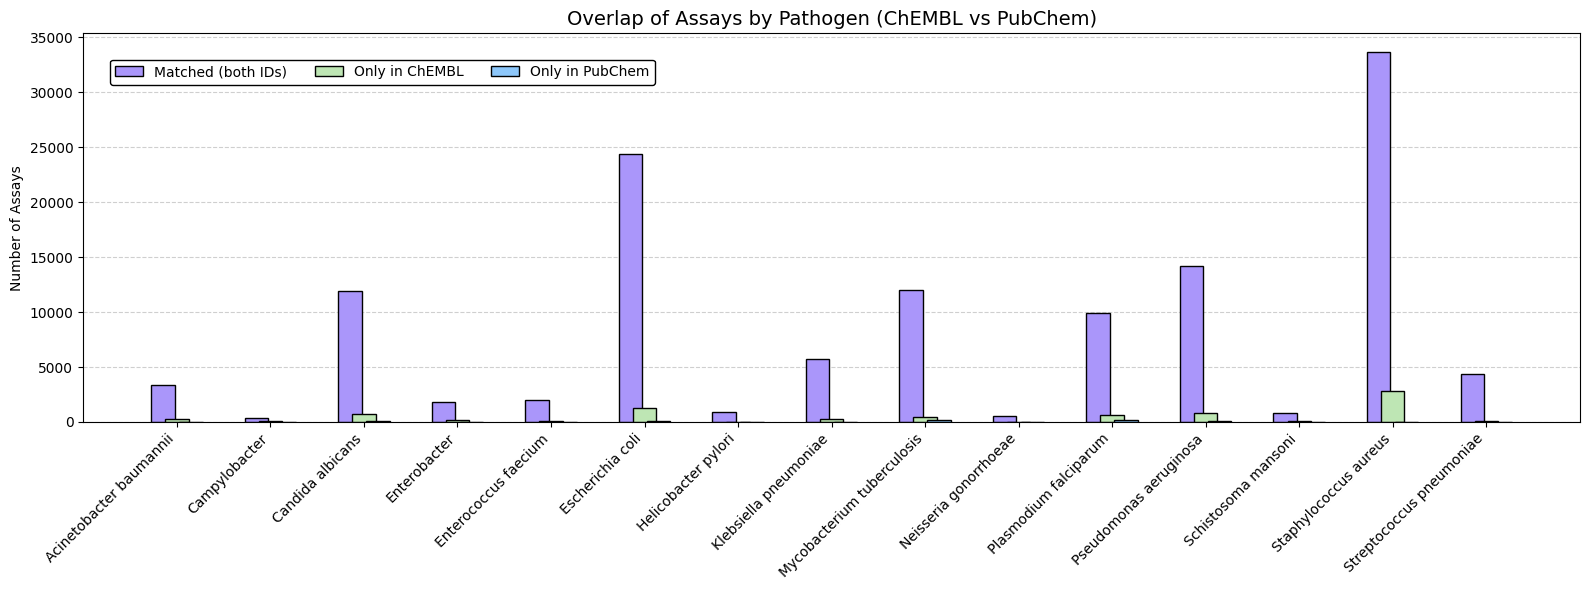

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Reuse your existing dataframe
df = id_overlap_summary.copy()

# Values
labels         = df["Pathogen"].values
matched        = df["Matched_in_summary"].values
only_chembl    = df["Only_ChEMBL"].values
only_pubchem   = df["Only_PubChem"].values

N = len(labels)
x = np.arange(N)

bar_width = 0.25
bar_spacing = 0  # controls the separation inside each group

# Colors
color_matched      = "#AA96FA"  # purple
color_only_chembl  = "#BEE6B4"  # green
color_only_pubchem = "#8DC7FA"  # light blue

# Plot
plt.figure(figsize=(16, 6))

plt.bar(x - spacing, matched, width=bar_width,
        color=color_matched, edgecolor="black", zorder=2, label="Matched (both IDs)")

plt.bar(x, only_chembl, width=bar_width,
        color=color_only_chembl, edgecolor="black", zorder=2, label="Only in ChEMBL")

plt.bar(x + spacing, only_pubchem, width=bar_width,
        color=color_only_pubchem, edgecolor="black", zorder=2, label="Only in PubChem")

# Labels and layout
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Number of Assays")
plt.title("Overlap of Assays by Pathogen (ChEMBL vs PubChem)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6, zorder=1)

# Legend at bottom
plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.2, 0.85),
    ncol=3,
    framealpha=1,
    edgecolor="k",
    prop={"size": 10}
)

plt.tight_layout()
plt.show()